# Imports

In [130]:
import torch
from datetime import datetime
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn as nn
import numpy as np
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('../')
from src.utils.data_preprocessing import load_processed_data
from src.utils.model_training import ModelTrainer
from src.models.vgg16_1D import VGG16_1D

# Variables

In [131]:
CLASS_NAMES = ['MI', 'NORM', 'OTHER']
PREPROCESSED_DIR = f"../data/preprocessed/"

date_today = '2025_09_01' #datetime.now().strftime("%Y_%m_%d")
MODEL_PATH = f"../src/models/trained/vgg16_1d_trained_{date_today}.pth"
HISTORY_PATH = f"../data/results/training_history/training_history_{date_today}.csv"
CHECKPOINT_PATH = f'../src/models/checkpoints/checkpoint_{date_today}.pth'

# Load Data

In [132]:
X_train, y_train = load_processed_data(PREPROCESSED_DIR, "train", class_names=CLASS_NAMES)
X_val, y_val = load_processed_data(PREPROCESSED_DIR, "val", class_names=CLASS_NAMES)
X_test, y_test = load_processed_data(PREPROCESSED_DIR, "test", class_names=CLASS_NAMES)

Loading processed data from ../data/preprocessed/ with prefix train
Loading processed data from ../data/preprocessed/ with prefix val
Loading processed data from ../data/preprocessed/ with prefix test
Loading processed data from ../data/preprocessed/ with prefix val
Loading processed data from ../data/preprocessed/ with prefix test


In [133]:
splits = {'Train': y_train, 'Validation': y_val, 'Test': y_test}

for split_name, y_split in splits.items():
    y_arr = np.asarray(y_split)
    # Multi-Label: Summiere pro Klasse (Spalte)
    if y_arr.ndim == 2 and y_arr.shape[1] == len(CLASS_NAMES):
        counts = y_arr.sum(axis=0)
    else:
        counts = np.bincount(y_arr, minlength=len(CLASS_NAMES))
    perc = counts / counts.sum() * 100
    print(f"{split_name}:")
    for name, c, p in zip(CLASS_NAMES, counts, perc):
        print(f"  {name}: {int(c)} ({p:.2f}%)")
    print(f"  TOTAL: {int(counts.sum())} (100.00%)\n")

Train:
  MI: 4379 (25.63%)
  NORM: 7595 (44.46%)
  OTHER: 5110 (29.91%)
  TOTAL: 17084 (100.00%)

Validation:
  MI: 540 (25.16%)
  NORM: 955 (44.50%)
  OTHER: 651 (30.34%)
  TOTAL: 2146 (100.00%)

Test:
  MI: 550 (25.49%)
  NORM: 963 (44.62%)
  OTHER: 645 (29.89%)
  TOTAL: 2158 (100.00%)



In [134]:
# [Batch_Size, Sequence_Length, Channels] 
X_test.shape

(2158, 1000, 12)

# Load Model

In [135]:
# y_train enthält alle Trainingslabels als Multi-Hot (Multi-Label)
if isinstance(y_train, np.ndarray) and y_train.ndim == 2:
    class_counts = y_train.sum(axis=0)
else:
    class_counts = np.bincount(y_train)

class_weights = 1.0 / class_counts   # Inverse Häufigkeit
class_weights = class_weights / class_weights.sum() * len(class_counts)  # Normierung
class_weights = torch.tensor(class_weights, dtype=torch.float32)

In [136]:
model = VGG16_1D(in_channels=12, num_classes=len(CLASS_NAMES), input_length=1000)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights)
trainer = ModelTrainer(model, None, None, optimizer, criterion)

trainer.load_model(MODEL_PATH)
trainer.load_training_history(HISTORY_PATH)

c:\Users\AliceKitchkin\Repos\ECG_xAI\notebooks\..\src\utils\model_training.py:272: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(path, 

Trainingshistorie aus '../data/results/training_history/training_history_2025_09_01.csv' erfolgreich geladen.


In [137]:
print("model.flattened_size:", model.flattened_size)
print("classifier[0].in_features:", model.classifier[0].in_features)
print("classifier[0].weight.shape:", model.classifier[0].weight.shape)

model.flattened_size: 15872
classifier[0].in_features: 15872
classifier[0].weight.shape: torch.Size([4096, 15872])


# Integrated Gradients

In [ ]:
model.eval()

In [180]:
def grab_samples(y_test, target_label_name, sample_size=5):
    # Target-Index finden
    target_idx = CLASS_NAMES.index(target_label_name)
    
    # Alle Samples mit dem gewünschten Label finden
    y_test_array = np.array(y_test)
    if y_test_array.ndim == 2:  # Multi-label format
        sample_indices = np.where(y_test_array[:, target_idx] == 1)[0]
    else:  # Single-label format
        sample_indices = np.where(y_test_array == target_idx)[0]
    
    sample_size_max = len(sample_indices)
    sample_size = sample_size_max if sample_size > sample_size_max else sample_size
    
    # maximal bis sample_size, für schnellere Berechnung, zufällig auswählen
    if sample_size_max > sample_size:
        sample_indices = np.random.choice(sample_indices, size=sample_size, replace=False)
    # else: take all samples

    print(f"Zufällig verarbeitete {target_label_name}-Samples: {len(sample_indices)} von {sample_size_max} (max)")
    return sample_indices, target_idx

In [181]:
from tqdm import tqdm
def compute_integrated_gradients_for_label(model, X_test, sample_indices, target_idx):
    ig = IntegratedGradients(model)

    # Attributionen für alle gefundenen Samples berechnen
    all_attributions = []

    for i, sample_idx in enumerate(tqdm(sample_indices, desc=f"Computing attributions for target {target_idx}")):
        # Input-Daten vorbereiten
        sample_data = torch.tensor(X_test[sample_idx:sample_idx+1]).float()
        sample_data = sample_data.transpose(1, 2)  # [1, 1000, 12]
        
        # Baseline (Nullvektor)
        baseline = torch.zeros_like(sample_data)
        
        # Attribution berechnen (für die Target-Klasse)
        attribution = ig.attribute(sample_data, target=target_idx, baselines=baseline)
        
        # Speichern
        all_attributions.append(attribution.detach().numpy())

    return all_attributions, sample_indices

In [182]:
sample_indices, target_idx = grab_samples(y_test, "MI", sample_size=10)
attributions_MI, sample_indices_MI = compute_integrated_gradients_for_label(model, X_test, sample_indices, target_idx)

Zufällig verarbeitete MI-Samples: 10 von 550 (max)


Computing attributions for target 0: 100%|██████████| 10/10 [00:06<00:00,  1.49it/s]


In [183]:
sample_indices, target_idx = grab_samples(y_test, "NORM", sample_size=10)
attributions_NORM, sample_indices_NORM = compute_integrated_gradients_for_label(model, X_test, sample_indices, target_idx)

Zufällig verarbeitete NORM-Samples: 10 von 963 (max)


Computing attributions for target 1: 100%|██████████| 10/10 [00:06<00:00,  1.51it/s]


In [184]:
sample_indices, target_idx = grab_samples(y_test, "OTHER", sample_size=10)
attributions_OTHER, sample_indices_OTHER = compute_integrated_gradients_for_label(model, X_test, sample_indices, target_idx)

Zufällig verarbeitete OTHER-Samples: 10 von 645 (max)


Computing attributions for target 2: 100%|██████████| 10/10 [00:06<00:00,  1.53it/s]


## Alle Labels

In [ ]:
# ECG-Ableitungsnamen (Standard 12-Lead ECG)
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

In [ ]:
# Attribution-Verteilungsanalyse
attr_flat = attributions[0].detach().numpy().flatten()

print("=== ATTRIBUTION ANALYSIS ===")
print(f"Total Attribution-Werte: {len(attr_flat)}")
print(f"Min: {np.min(attr_flat):.6f}")
print(f"Max: {np.max(attr_flat):.6f}")
print(f"Mean: {np.mean(attr_flat):.6f}")
print(f"Std: {np.std(attr_flat):.6f}")
print()

# Prozentuale Verteilung
threshold_low = 0.0001
threshold_high = -0.0001
neutral = np.sum((attr_flat >= threshold_high) & (attr_flat <= threshold_low))
positive = np.sum(attr_flat > threshold_low)
negative = np.sum(attr_flat < threshold_high)

print(f"Neutral (≈0): {neutral} ({neutral/len(attr_flat)*100:.1f}%)")
print(f"Positive: {positive} ({positive/len(attr_flat)*100:.1f}%)")
print(f"Negative: {negative} ({negative/len(attr_flat)*100:.1f}%)")
print()

print(f"")

# Top Attribution-Werte
print("=== TOP POSITIVE ATTRIBUTIONS ===")
top_pos_idx = np.argsort(attr_flat)[-10:]
for i, idx in enumerate(top_pos_idx[::-1]):
    lead = idx // 1000
    time = idx % 1000
    print(f"{i+1}. Lead {lead_names[lead]}, Time {time}: {attr_flat[idx]:.6f}")

print("\n=== TOP NEGATIVE ATTRIBUTIONS ===")
top_neg_idx = np.argsort(attr_flat)[:10]
for i, idx in enumerate(top_neg_idx):
    lead = idx // 1000
    time = idx % 1000
    print(f"{i+1}. Lead {lead_names[lead]}, Time {time}: {attr_flat[idx]:.6f}")

## Label: MI

## Label: NORM

## Label: OTHER

Attribution range: -0.720981 to 0.720981


C:\Users\AliceKitchkin\AppData\Local\Temp\ipykernel_31932\1643361862.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


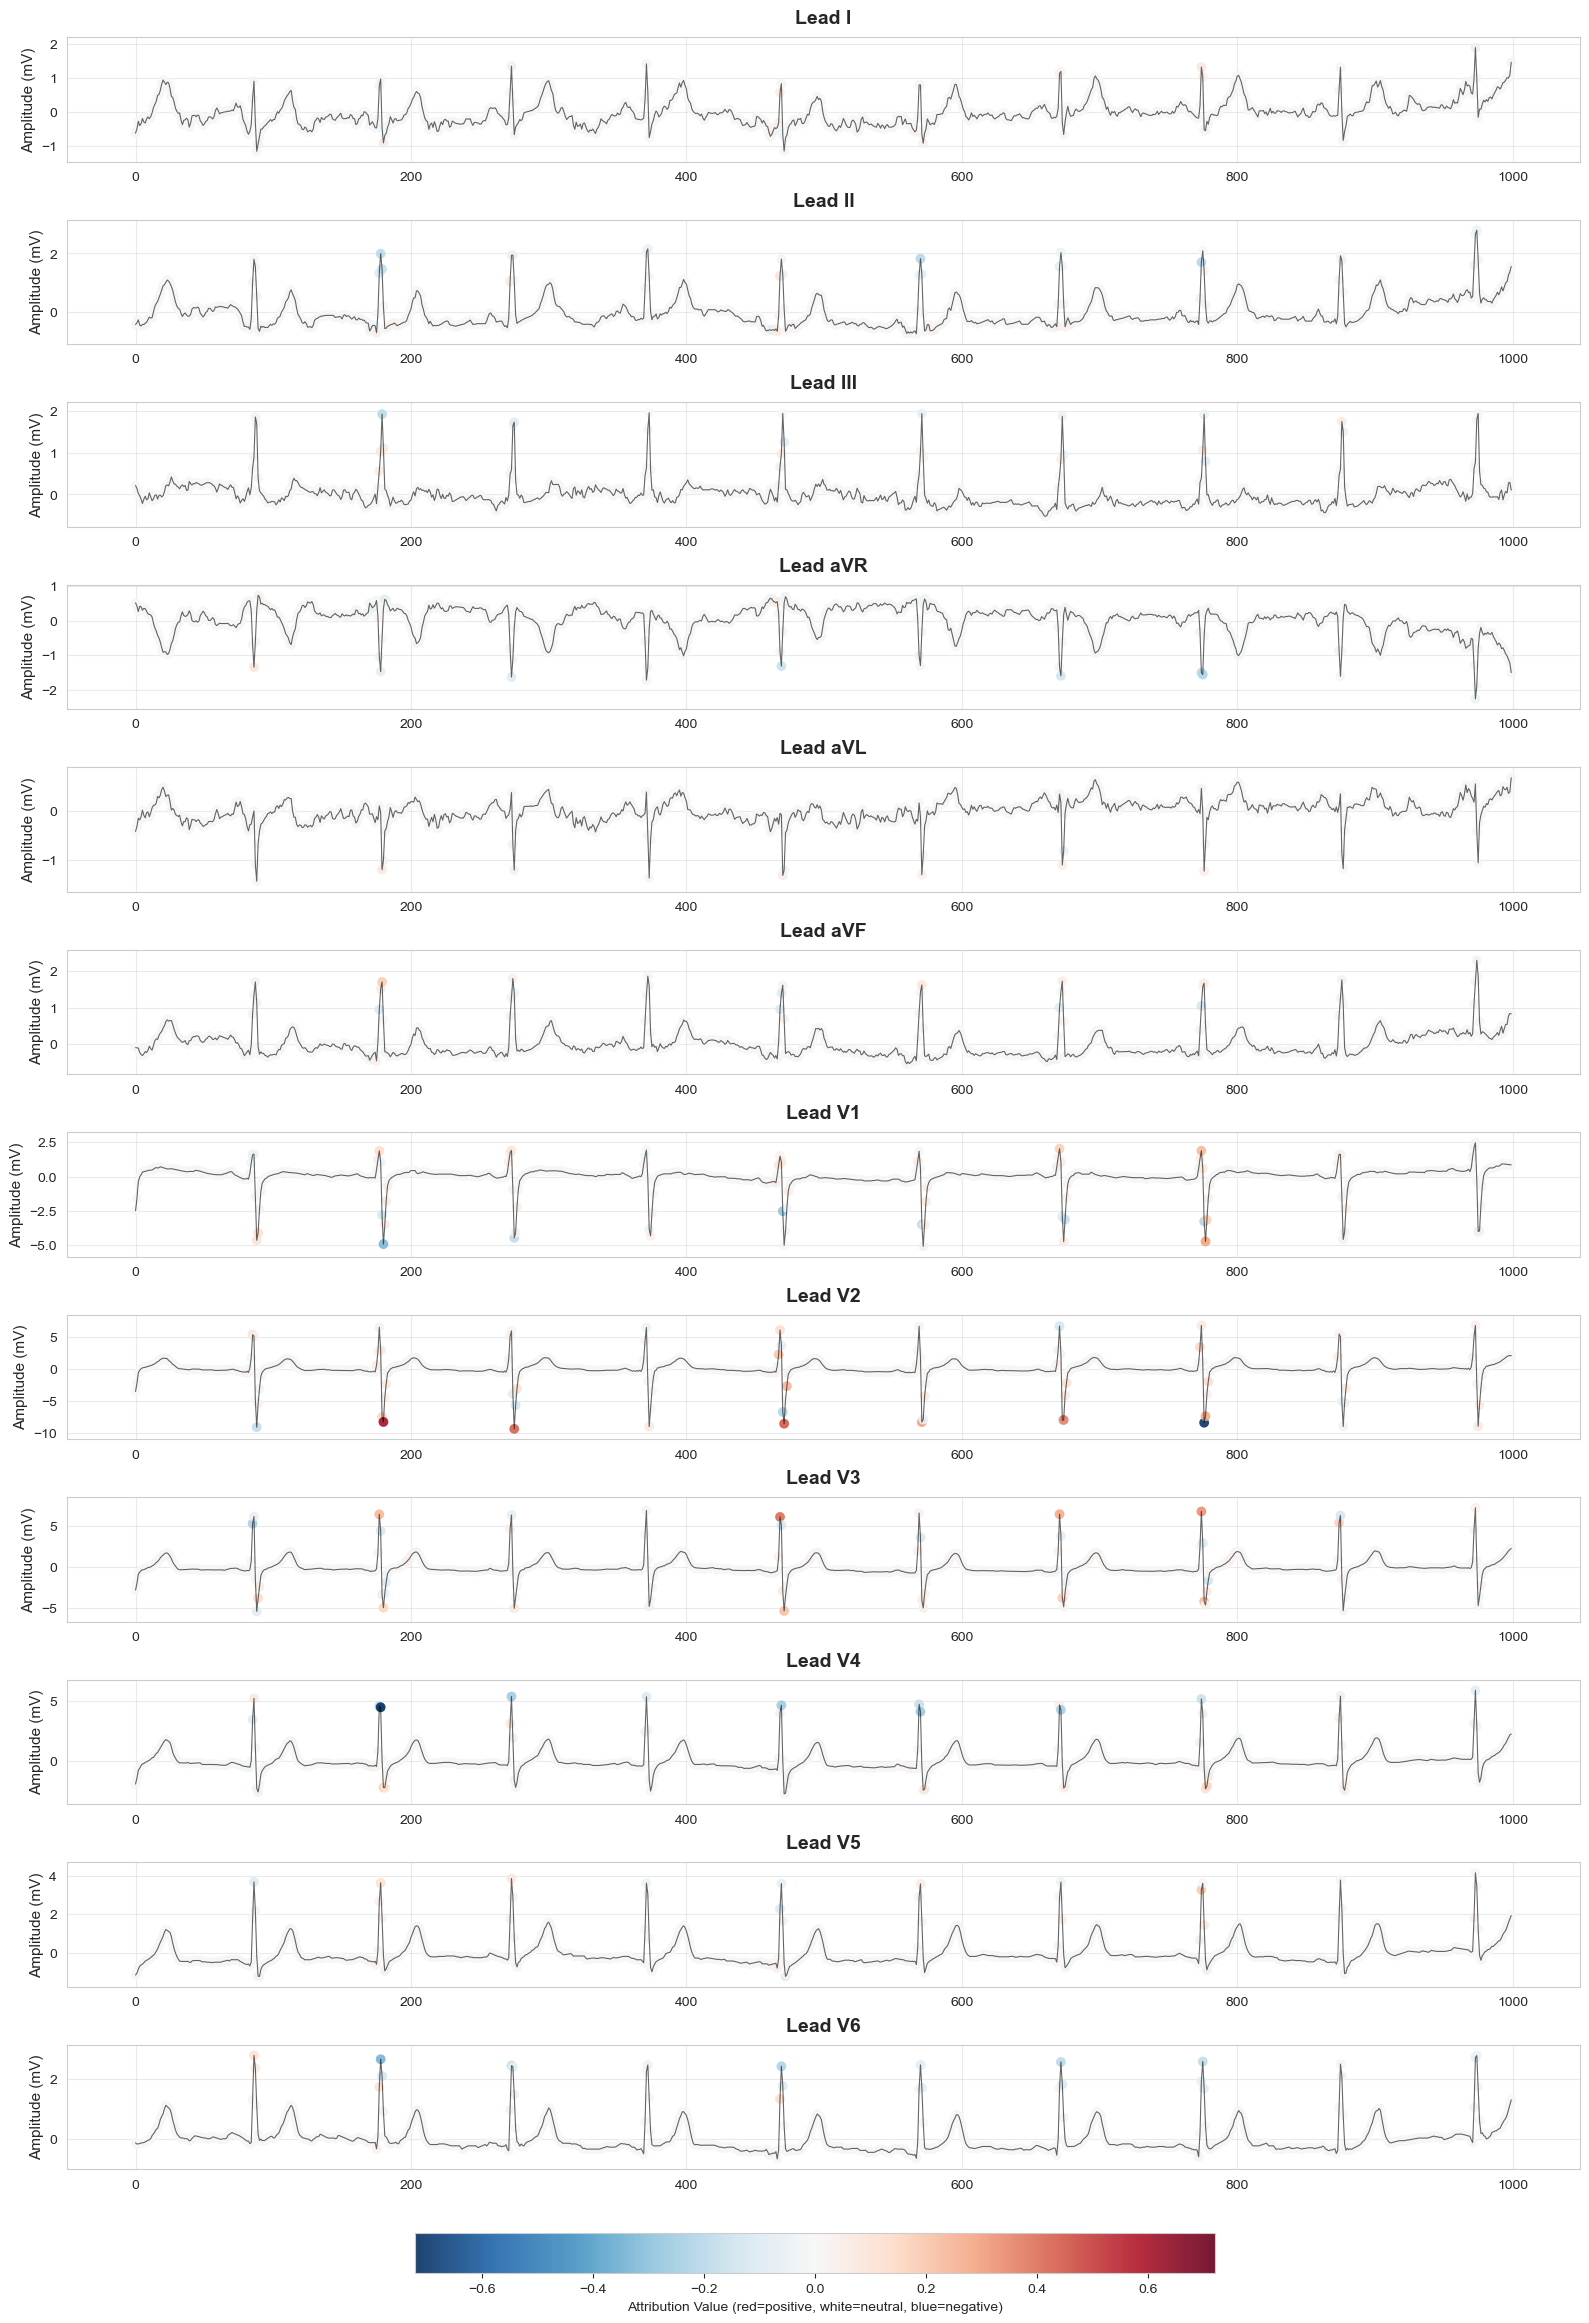

In [144]:
# Visualisierung: Alle ECG-Ableitungen untereinander
fig, axes = plt.subplots(12, 1, figsize=(16, 26))

# Normalisierung der Attribution-Werte für bessere Farbdarstellung
attr_values_all = attributions[0].detach().numpy()
# Symmetrische Farbskala um 0 (weiß in der Mitte)
vmax_abs = max(abs(np.min(attr_values_all)), abs(np.max(attr_values_all)))
vmin = -vmax_abs
vmax = vmax_abs

time_steps = np.arange(1000)

print(f"Attribution range: {vmin:.6f} to {vmax:.6f}")

for i in range(12):
    ax = axes[i]
    
    # ECG-Signal extrahieren - korrekte Indexierung: [batch, channel, time]
    ecg_signal = input_data[0, i, :].detach().numpy()  # [1000] - Zeitschritte für Kanal i
    
    # Attribution-Werte für diese Ableitung
    attr_values = attributions[0, i, :].detach().numpy()  # [1000] - Zeitschritte für Kanal i
    
    # ECG-Signal als dünne schwarze Linie plotten
    ax.plot(time_steps, ecg_signal, 'k-', linewidth=0.8, alpha=0.6, label='ECG Signal')
    
    # Attribution-Werte als farbkodierte Punkte über das Signal legen
    # Alle Punkte anzeigen
    scatter = ax.scatter(time_steps, ecg_signal, c=attr_values, 
                        cmap='RdBu_r', s=50, alpha=0.9, 
                        vmin=vmin, vmax=vmax, edgecolors='none')
    
    # Titel und Achsenbeschriftung
    ax.set_title(f'Lead {lead_names[i]}', fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('Amplitude (mV)', fontsize=11)
    ax.grid(True, alpha=0.4)
    
    # Y-Achse limits für bessere Sichtbarkeit
    signal_range = np.max(ecg_signal) - np.min(ecg_signal)
    margin = signal_range * 0.1 if signal_range > 0 else 0.1
    ax.set_ylim(np.min(ecg_signal) - margin, np.max(ecg_signal) + margin)
    
    # X-Achse nur beim letzten Plot beschriften
    # if i == 11:
    #     ax.set_xlabel('Time Steps', fontsize=12)
    # else:
    #     ax.set_xticks([])

# Colorbar für die Attribution-Werte
cbar = plt.colorbar(scatter, ax=axes, orientation='horizontal', 
                   fraction=0.02,  # sehr schmal
                   pad=0.15,       # mehr Abstand
                   shrink=0.8,     # 80% der Breite
                   anchor=(0.5, 0.0))  # zentriert
cbar.set_label('Attribution Value (red=positive, white=neutral, blue=negative)', fontsize=10)

plt.tight_layout()
plt.subplots_adjust(top=0.97, bottom=0.15)  # mehr Platz unten
plt.show()

=== ATTRIBUTION ANALYSIS ===
Total Attribution-Werte: 12000
Min: -0.720981
Max: 0.601255
Mean: -0.000016
Std: 0.022373

Neutral (≈0): 1385 (11.5%)
Positive: 5098 (42.5%)
Negative: 5517 (46.0%)


=== TOP POSITIVE ATTRIBUTIONS ===
1. Lead V2, Time 180: 0.601255
2. Lead V2, Time 471: 0.441518
3. Lead V2, Time 275: 0.428875
4. Lead V3, Time 468: 0.403339
5. Lead V2, Time 674: 0.357955
6. Lead V3, Time 774: 0.327999
7. Lead V2, Time 571: 0.303899
8. Lead V1, Time 777: 0.288781
9. Lead V3, Time 671: 0.271161
10. Lead V2, Time 777: 0.268041

=== TOP NEGATIVE ATTRIBUTIONS ===
1. Lead V4, Time 178: -0.720981
2. Lead V2, Time 776: -0.703080
3. Lead V6, Time 178: -0.332750
4. Lead V1, Time 180: -0.321867
5. Lead V1, Time 470: -0.282173
6. Lead V4, Time 570: -0.270051
7. Lead V4, Time 469: -0.258723
8. Lead V4, Time 273: -0.255953
9. Lead V4, Time 672: -0.233013
10. Lead V3, Time 85: -0.231546


C:\Users\AliceKitchkin\AppData\Local\Temp\ipykernel_31932\296114022.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=11)


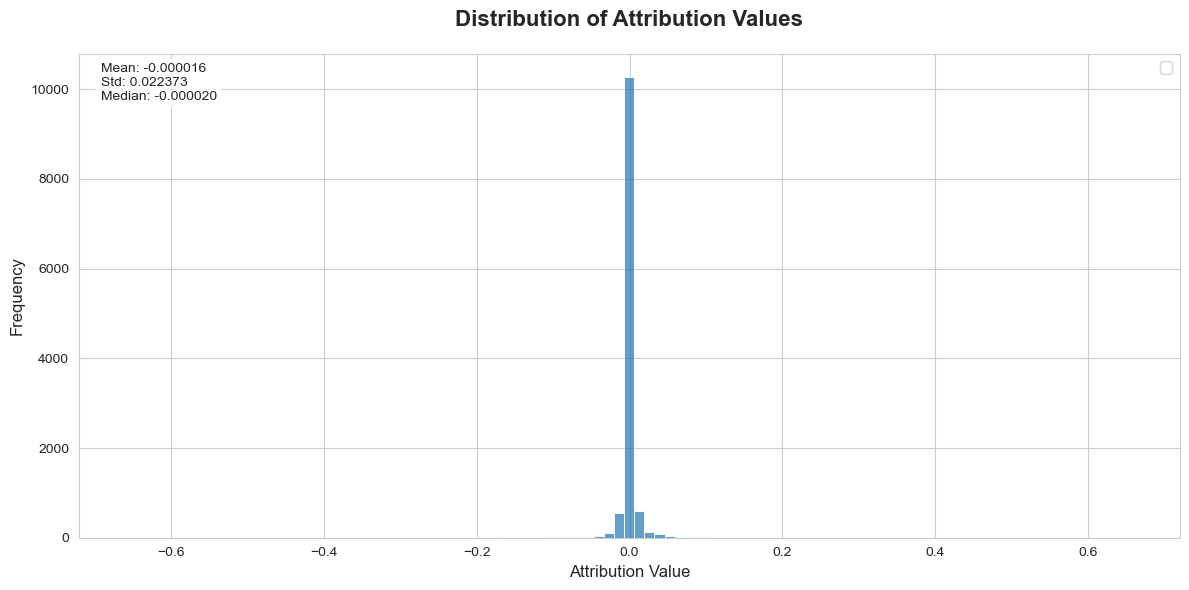

In [146]:
# Histogram der Attribution-Werte mit Seaborn
plt.figure(figsize=(12, 6))
#sns.set_style("whitegrid")

# Haupthistogramm
ax = sns.histplot(attr_flat, bins=100, alpha=0.7)

# X-Achse symmetrisch um 0 zentrieren
max_abs_value = max(abs(np.min(attr_flat)), abs(np.max(attr_flat)))
ax.set_xlim(-max_abs_value, max_abs_value)

# Stil anpassen
plt.title('Distribution of Attribution Values', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Attribution Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=11)

# Zusätzliche Statistiken als Text
stats_text = f'Mean: {np.mean(attr_flat):.6f}\nStd: {np.std(attr_flat):.6f}\nMedian: {np.median(attr_flat):.6f}'
plt.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [147]:
# =================================================================
# COMPLETENESS CHECK für Integrated Gradients
# =================================================================

print("=== COMPLETENESS AXIOM VERIFICATION ===")
print("Integrated Gradients sollte: Σ(Attributionen) = f(x) - f(baseline)")
print()


# Modell-Vorhersagen für alle Klassen
with torch.no_grad():
    model_output_input = model(input_data)      # [1, 3] - alle Klassen
    model_output_baseline = model(baseline)     # [1, 3] - alle Klassen

print(f"Model Output Shape: {model_output_input.shape}")
print(f"Target Index: {sample_idx} ({CLASS_NAMES[sample_idx]})")
print()

# Differenz für die Target-Klasse (sample_idx = 0 = MI)
output_diff_target = model_output_input[0, sample_idx] - model_output_baseline[0, sample_idx]

# Summe der Attributionen (über alle 12 Kanäle und 1000 Zeitpunkte)
attr_sum_total = attributions.sum()

print("=== COMPLETENESS FÜR TARGET-KLASSE ===")
print(f"  Modell Output (Input):    {model_output_input[0, sample_idx]:.6f}")
print(f"  Modell Output (Baseline): {model_output_baseline[0, sample_idx]:.6f}")
print(f"  Differenz f(x) - f(b):    {output_diff_target:.6f}")
print(f"  Summe Attributionen:      {attr_sum_total:.6f}")
print(f"  Completeness Error:       {abs(output_diff_target - attr_sum_total):.6f}")

=== COMPLETENESS AXIOM VERIFICATION ===
Integrated Gradients sollte: Σ(Attributionen) = f(x) - f(baseline)

Model Output Shape: torch.Size([1, 3])
Target Index: 0 (MI)

=== COMPLETENESS FÜR TARGET-KLASSE ===
  Modell Output (Input):    -3.414459
  Modell Output (Baseline): -3.256543
  Differenz f(x) - f(b):    -0.157916
  Summe Attributionen:      -0.193279
  Completeness Error:       0.035363


In [148]:
# Berechne Attributionen für jede Klasse einzeln
print("Berechne Attributionen für alle Klassen...")

attributions_all_classes = {}
for target_idx, class_name in enumerate(CLASS_NAMES):
    print(f"  Berechne für {class_name} (Index {target_idx})...")
    attr_class = ig.attribute(input_data, target=target_idx, baselines=baseline)
    attributions_all_classes[class_name] = attr_class
    
    # Completeness Check für diese Klasse
    attr_sum = attr_class.sum()
    output_diff = model_output_input[0, target_idx] - model_output_baseline[0, target_idx]
    error = abs(output_diff - attr_sum)
    
    print(f"    Differenz: {output_diff:.6f}")
    print(f"    Attr-Summe: {attr_sum:.6f}")
    print(f"    Error: {error:.6f}")
    print()

Berechne Attributionen für alle Klassen...
  Berechne für MI (Index 0)...
    Differenz: -0.157916
    Attr-Summe: -0.193279
    Error: 0.035363

  Berechne für NORM (Index 1)...
    Differenz: -0.157916
    Attr-Summe: -0.193279
    Error: 0.035363

  Berechne für NORM (Index 1)...
    Differenz: 3.540442
    Attr-Summe: 3.554550
    Error: 0.014107

  Berechne für OTHER (Index 2)...
    Differenz: 3.540442
    Attr-Summe: 3.554550
    Error: 0.014107

  Berechne für OTHER (Index 2)...
    Differenz: -3.574289
    Attr-Summe: -3.548959
    Error: 0.025330

    Differenz: -3.574289
    Attr-Summe: -3.548959
    Error: 0.025330



In [149]:
# =================================================================
# MULTI-SAMPLE ATTRIBUTION ANALYSE für MI-Klasse
# =================================================================

print("=== MULTI-SAMPLE ANALYSE: MI-Klasse ===")
print()

# Finde alle MI-Samples im Test-Set
y_test_array = np.array(y_test)
if y_test_array.ndim == 2:  # Multi-label format
    mi_indices = np.where(y_test_array[:, 0] == 1)[0]  # MI ist Index 0
else:  # Single-label format
    mi_indices = np.where(y_test_array == 0)[0]

print(f"Gefundene MI-Samples im Test-Set: {len(mi_indices)}")
print(f"Erste 10 Indices: {mi_indices[:10]}")
print()

# Wähle mehrere MI-Samples aus (z.B. erste 5)
num_samples = min(5, len(mi_indices))
selected_mi_indices = mi_indices[:num_samples]

print(f"Analysiere {num_samples} MI-Samples: {selected_mi_indices}")
print()

# Sammle Attributionen für alle ausgewählten Samples
all_attributions = []
sample_info = []

for i, sample_idx in enumerate(selected_mi_indices):
    print(f"Verarbeite Sample {i+1}/{num_samples}: Index {sample_idx}")
    
    # Input-Daten vorbereiten
    sample_data = torch.tensor(X_test[sample_idx:sample_idx+1]).float()
    sample_data = sample_data.transpose(1, 2)  # [1, 1000, 12]
    
    # Baseline
    sample_baseline = torch.zeros_like(sample_data)
    
    # Attribution berechnen (für MI-Klasse = target 0)
    sample_attr = ig.attribute(sample_data, target=0, baselines=sample_baseline)
    
    # Modell-Vorhersagen
    with torch.no_grad():
        predictions = model(sample_data)
        predicted_class = torch.argmax(predictions, dim=1).item()
        confidence = torch.softmax(predictions, dim=1)[0]
    
    # Speichern
    all_attributions.append(sample_attr.detach().numpy())
    sample_info.append({
        'index': sample_idx,
        'predictions': predictions[0].detach().numpy(),
        'predicted_class': predicted_class,
        'predicted_name': CLASS_NAMES[predicted_class],
        'confidences': confidence.detach().numpy()
    })
    
    print(f"  Vorhersage: {CLASS_NAMES[predicted_class]} (Confidence: {confidence[predicted_class]:.3f})")
    print(f"  MI-Score: {confidence[0]:.3f}, NORM-Score: {confidence[1]:.3f}, OTHER-Score: {confidence[2]:.3f}")
    print()

print("=== SAMPLE-ÜBERSICHT ===")
for i, info in enumerate(sample_info):
    print(f"Sample {i+1} (Index {info['index']}):")
    print(f"  Vorhergesagt: {info['predicted_name']}")
    print(f"  MI-Confidence: {info['confidences'][0]:.3f}")
    print()

# Berechne durchschnittliche Attributionen
avg_attributions = np.mean(all_attributions, axis=0)  # [1, 1000, 12]
std_attributions = np.std(all_attributions, axis=0)   # [1, 1000, 12]

print("=== DURCHSCHNITTLICHE ATTRIBUTIONEN BERECHNET ===")
print(f"Shape: {avg_attributions.shape}")
print(f"Mean Attribution: {np.mean(avg_attributions):.6f}")
print(f"Std der Mittelwerte: {np.mean(std_attributions):.6f}")
print()

=== MULTI-SAMPLE ANALYSE: MI-Klasse ===

Gefundene MI-Samples im Test-Set: 550
Erste 10 Indices: [ 5 24 27 32 34 39 40 56 65 66]

Analysiere 5 MI-Samples: [ 5 24 27 32 34]

Verarbeite Sample 1/5: Index 5
  Vorhersage: MI (Confidence: 0.866)
  MI-Score: 0.866, NORM-Score: 0.127, OTHER-Score: 0.007

Verarbeite Sample 2/5: Index 24
  Vorhersage: MI (Confidence: 0.866)
  MI-Score: 0.866, NORM-Score: 0.127, OTHER-Score: 0.007

Verarbeite Sample 2/5: Index 24
  Vorhersage: OTHER (Confidence: 0.860)
  MI-Score: 0.138, NORM-Score: 0.002, OTHER-Score: 0.860

Verarbeite Sample 3/5: Index 27
  Vorhersage: OTHER (Confidence: 0.860)
  MI-Score: 0.138, NORM-Score: 0.002, OTHER-Score: 0.860

Verarbeite Sample 3/5: Index 27
  Vorhersage: NORM (Confidence: 0.982)
  MI-Score: 0.013, NORM-Score: 0.982, OTHER-Score: 0.005

Verarbeite Sample 4/5: Index 32
  Vorhersage: NORM (Confidence: 0.982)
  MI-Score: 0.013, NORM-Score: 0.982, OTHER-Score: 0.005

Verarbeite Sample 4/5: Index 32
  Vorhersage: MI (Confid

=== VISUALISIERUNG: Durchschnittliche MI-Attributionen ===
Average ECG shape: (12, 1000)
avg_attributions shape: (1, 12, 1000)
Durchschnittliche Attribution Range: -0.160943 to 0.160943


C:\Users\AliceKitchkin\AppData\Local\Temp\ipykernel_31932\2591946584.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


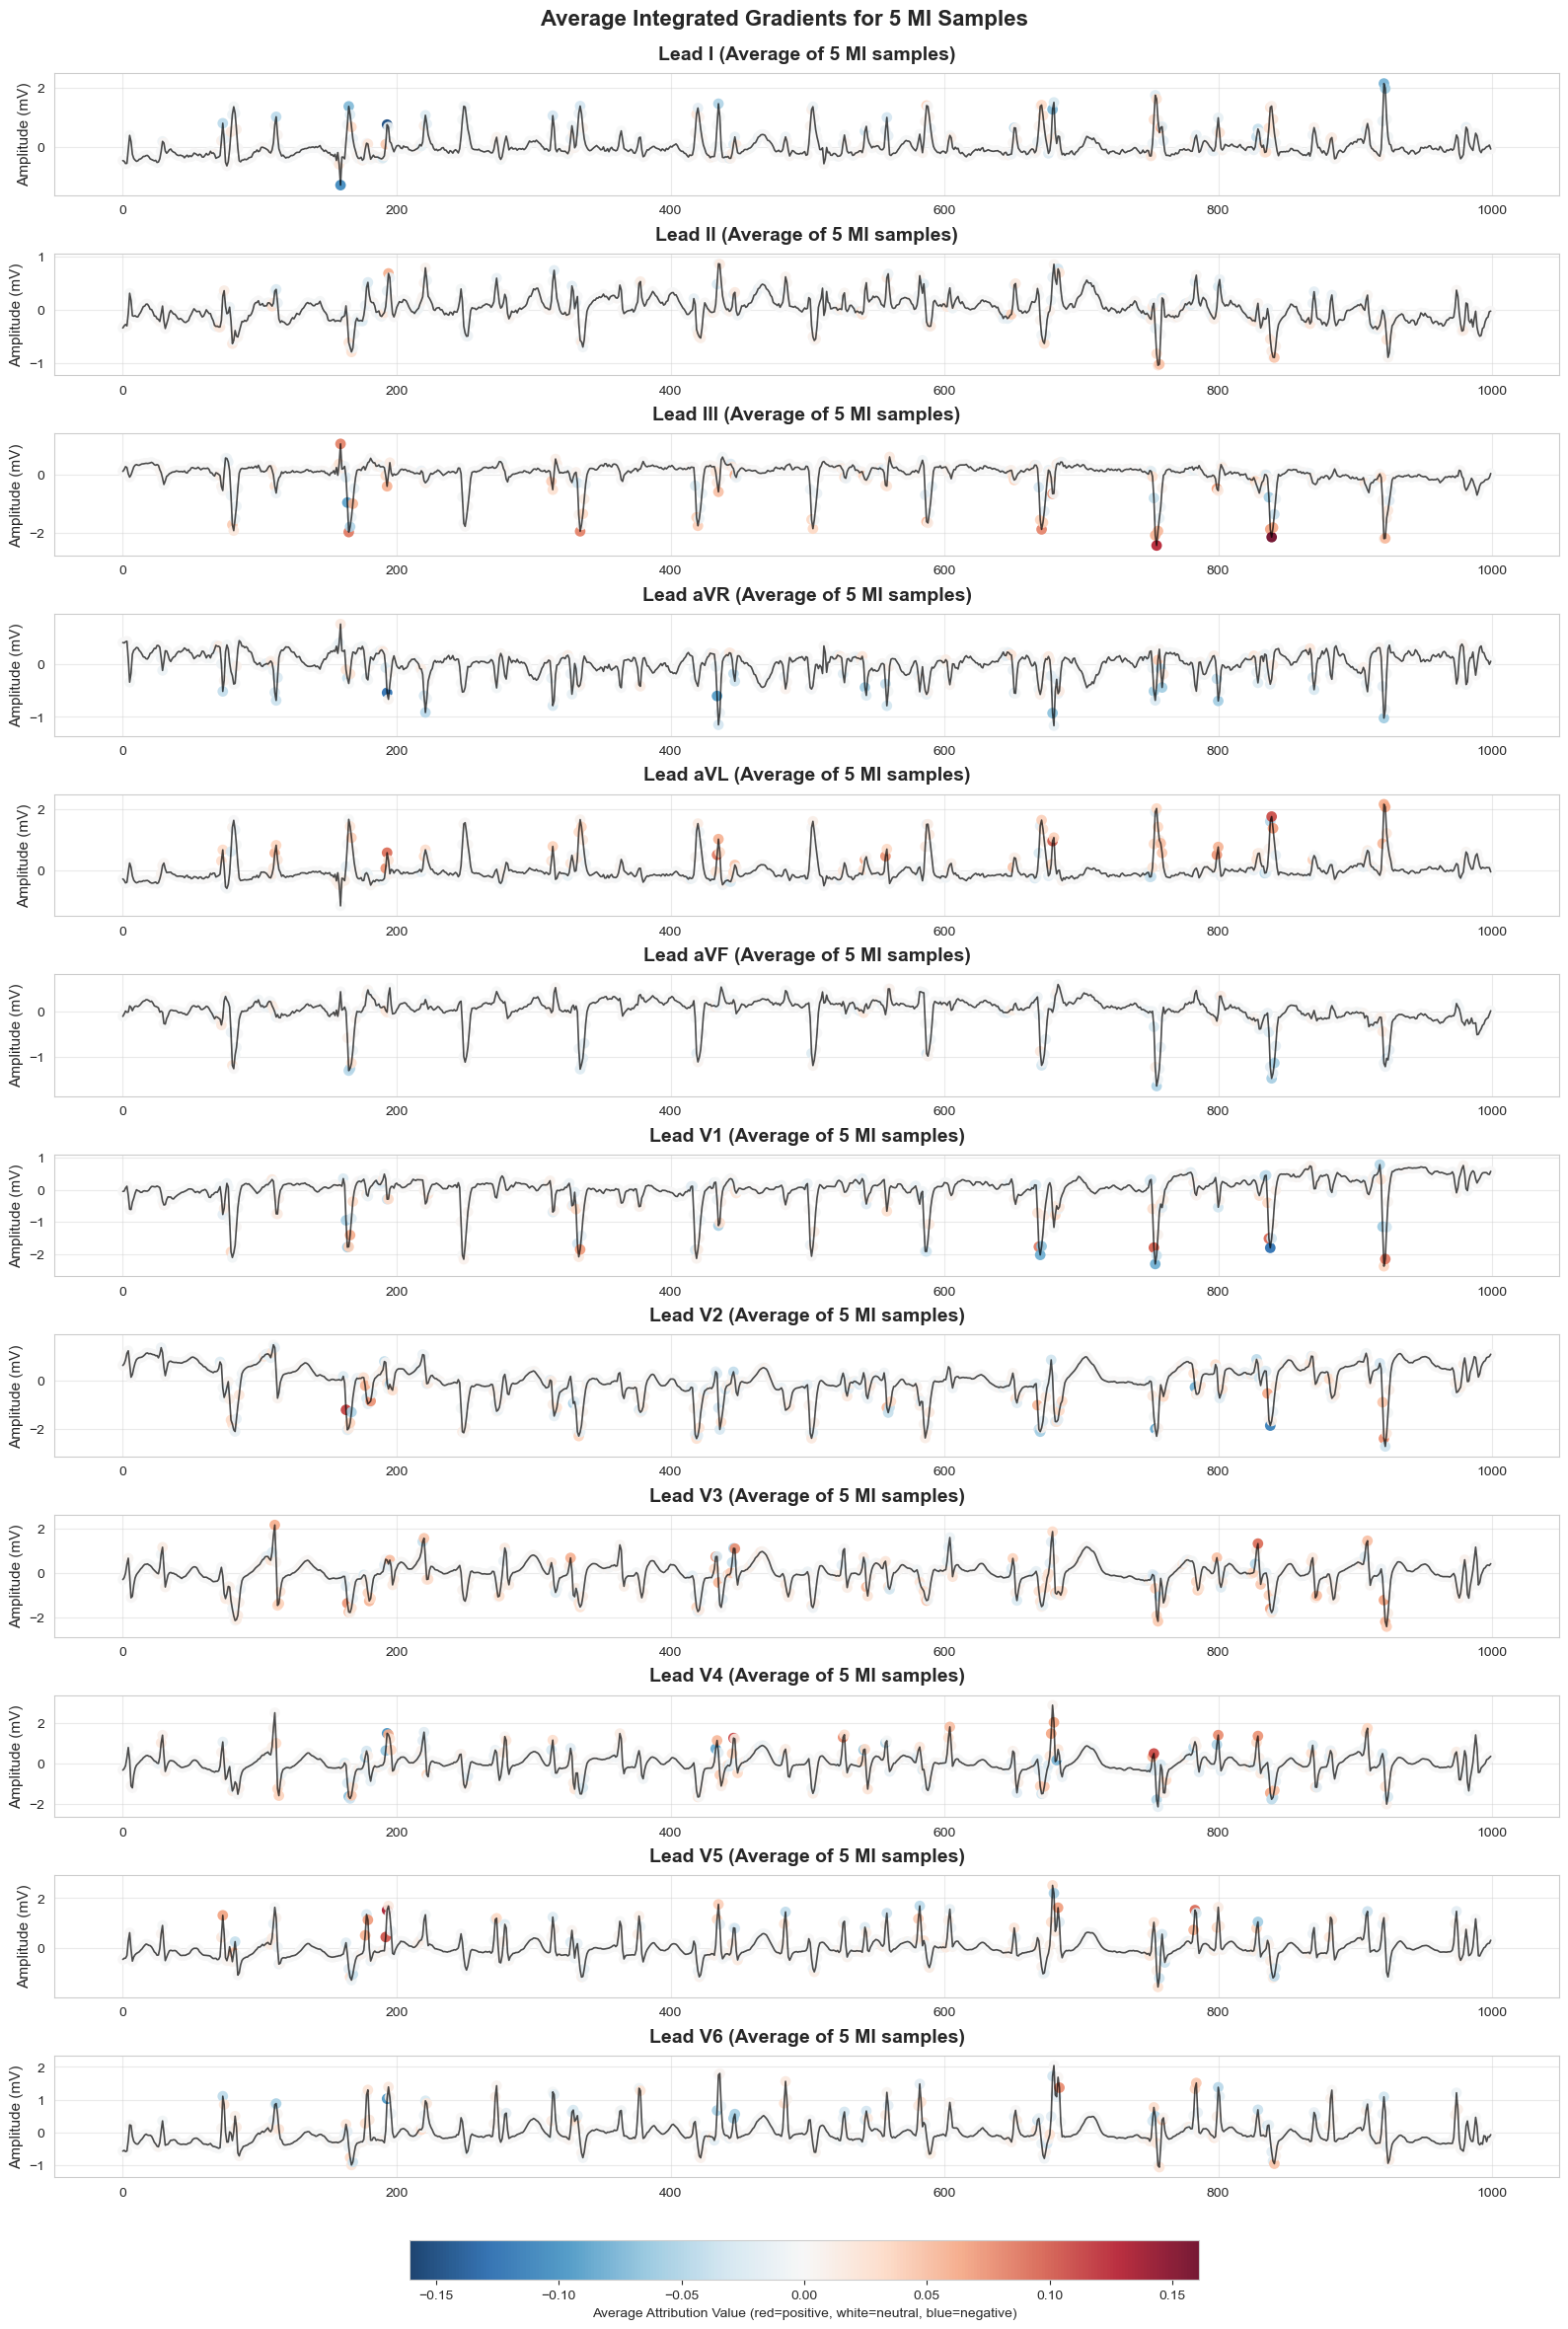


=== STATISTIKEN: Durchschnittliche Attributionen ===
Total Punkte: 12000
Min: -0.149584
Max: 0.160943
Mean: 0.000246
Std: 0.010738

=== TOP 5 POSITIVE ATTRIBUTIONS (Durchschnitt) ===
1. Lead III, Time 839: 0.160943
2. Lead V5, Time 193: 0.133321
3. Lead III, Time 755: 0.126019
4. Lead V2, Time 163: 0.112962
5. Lead V4, Time 446: 0.112460

=== TOP 5 NEGATIVE ATTRIBUTIONS (Durchschnitt) ===
1. Lead I, Time 193: -0.149584
2. Lead V1, Time 838: -0.125683
3. Lead aVR, Time 193: -0.125546
4. Lead V2, Time 838: -0.113511
5. Lead I, Time 159: -0.106258


In [150]:
# =================================================================
# VISUALISIERUNG: Durchschnittliche Attributionen für MI-Samples
# =================================================================

print("=== VISUALISIERUNG: Durchschnittliche MI-Attributionen ===")

# Durchschnittliche ECG-Signale berechnen
# X_test ist [samples, time, channels] = [2158, 1000, 12]
# avg_attributions ist [batch, channels, time] = [1, 12, 1000]

avg_ecg_signals = []
for sample_idx in selected_mi_indices:
    sample_data = X_test[sample_idx]  # [1000, 12] - Zeit x Kanäle
    # Transponieren zu [12, 1000] - Kanäle x Zeit (wie avg_attributions)
    sample_data_transposed = sample_data.T  # [12, 1000]
    avg_ecg_signals.append(sample_data_transposed)

avg_ecg = np.mean(avg_ecg_signals, axis=0)  # [12, 1000]
print(f"Average ECG shape: {avg_ecg.shape}")
print(f"avg_attributions shape: {avg_attributions.shape}")

# Visualisierung: Durchschnittliche Attributionen
fig, axes = plt.subplots(12, 1, figsize=(16, 26))

# Symmetrische Farbskala
attr_all = avg_attributions[0]  # [12, 1000]
vmax_abs = max(abs(np.min(attr_all)), abs(np.max(attr_all)))
vmin = -vmax_abs
vmax = vmax_abs

time_steps = np.arange(1000)

print(f"Durchschnittliche Attribution Range: {vmin:.6f} to {vmax:.6f}")

for i in range(12):
    ax = axes[i]
    
    # ECG-Signal für Lead i: avg_ecg ist [12, 1000]
    ecg_signal = avg_ecg[i, :]  # [1000] - Zeit-Schritte für Lead i
    
    # Attribution-Werte für Lead i: attr_all ist [12, 1000]
    attr_values = attr_all[i, :]  # [1000] - Zeit-Schritte für Lead i
    
    # Shapes sollten jetzt passen
    assert ecg_signal.shape == attr_values.shape == (1000,), f"Shape mismatch: ECG {ecg_signal.shape}, Attr {attr_values.shape}"
    
    # ECG-Signal plotten
    ax.plot(time_steps, ecg_signal, 'k-', linewidth=1.2, alpha=0.7, label='Avg ECG Signal')
    
    # Attribution-Werte als farbkodierte Punkte
    scatter = ax.scatter(time_steps, ecg_signal, c=attr_values, 
                        cmap='RdBu_r', s=60, alpha=0.9, 
                        vmin=vmin, vmax=vmax, edgecolors='none')
    
    # Titel
    ax.set_title(f'Lead {lead_names[i]} (Average of {num_samples} MI samples)', 
                fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('Amplitude (mV)', fontsize=11)
    ax.grid(True, alpha=0.4)
    
    # Y-Achse anpassen
    signal_range = np.max(ecg_signal) - np.min(ecg_signal)
    margin = signal_range * 0.1 if signal_range > 0 else 0.1
    ax.set_ylim(np.min(ecg_signal) - margin, np.max(ecg_signal) + margin)

# Colorbar
cbar = plt.colorbar(scatter, ax=axes, orientation='horizontal', 
                   fraction=0.02, pad=0.15, shrink=0.8, anchor=(0.5, 0.0))
cbar.set_label('Average Attribution Value (red=positive, white=neutral, blue=negative)', fontsize=10)

plt.suptitle(f'Average Integrated Gradients for {num_samples} MI Samples', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.subplots_adjust(top=0.97, bottom=0.15)
plt.show()

# Statistiken der durchschnittlichen Attributionen
attr_flat_avg = attr_all.flatten()
print()
print("=== STATISTIKEN: Durchschnittliche Attributionen ===")
print(f"Total Punkte: {len(attr_flat_avg)}")
print(f"Min: {np.min(attr_flat_avg):.6f}")
print(f"Max: {np.max(attr_flat_avg):.6f}")
print(f"Mean: {np.mean(attr_flat_avg):.6f}")
print(f"Std: {np.std(attr_flat_avg):.6f}")
print()

# Top Attribution-Bereiche
top_pos_idx = np.argsort(attr_flat_avg)[-5:]
print("=== TOP 5 POSITIVE ATTRIBUTIONS (Durchschnitt) ===")
for i, idx in enumerate(top_pos_idx[::-1]):
    lead = idx // 1000
    time = idx % 1000
    print(f"{i+1}. Lead {lead_names[lead]}, Time {time}: {attr_flat_avg[idx]:.6f}")

print()
top_neg_idx = np.argsort(attr_flat_avg)[:5]
print("=== TOP 5 NEGATIVE ATTRIBUTIONS (Durchschnitt) ===")
for i, idx in enumerate(top_neg_idx):
    lead = idx // 1000
    time = idx % 1000
    print(f"{i+1}. Lead {lead_names[lead]}, Time {time}: {attr_flat_avg[idx]:.6f}")

In [151]:
# DEBUG: Dimensionen überprüfen
print("=== DIMENSION DEBUG ===")
print(f"X_test shape: {X_test.shape}")
print(f"Sample X_test[5] shape: {X_test[5].shape}")
print(f"avg_attributions shape: {avg_attributions.shape}")

# Test: Ein einzelnes Sample
test_sample = X_test[5]  # Index 5 war eines unserer MI-Samples
print(f"Test sample shape: {test_sample.shape}")
print(f"Test sample Lead 0 shape: {test_sample[0, :].shape}")

# Vergleiche mit avg_attributions
print(f"avg_attributions[0] shape: {avg_attributions[0].shape}")
print(f"avg_attributions[0, 0, :] shape: {avg_attributions[0, 0, :].shape}")

=== DIMENSION DEBUG ===
X_test shape: (2158, 1000, 12)
Sample X_test[5] shape: (1000, 12)
avg_attributions shape: (1, 12, 1000)
Test sample shape: (1000, 12)
Test sample Lead 0 shape: (12,)
avg_attributions[0] shape: (12, 1000)
avg_attributions[0, 0, :] shape: (1000,)


=== BALKENDIAGRAMM: Attribution-Summen pro Ableitung ===


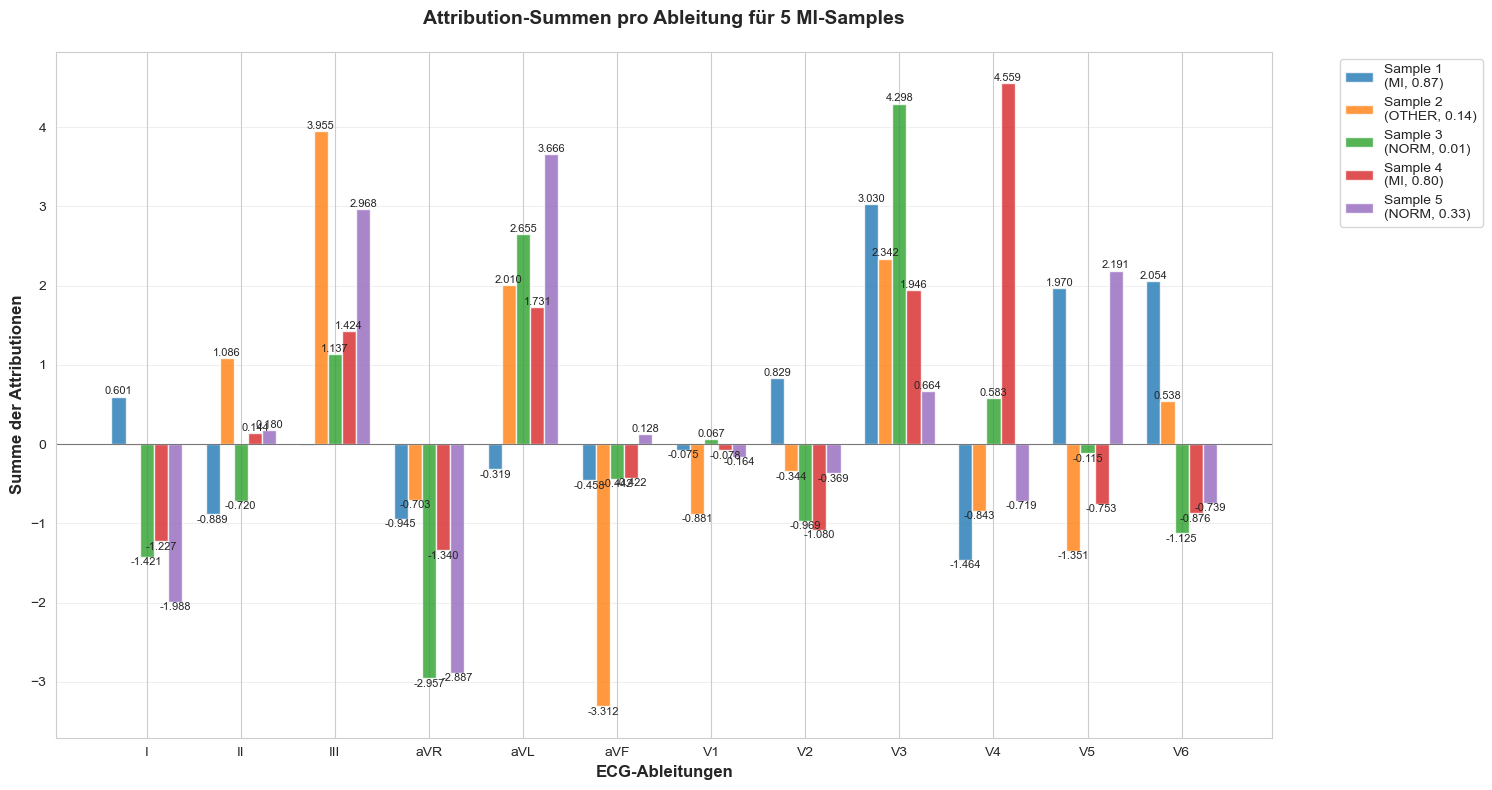


=== STATISTIKEN PRO ABLEITUNG (Durchschnitt über 5 Samples) ===
   I: Avg= -0.8106, Std=  0.9544
  II: Avg= -0.0399, Std=  0.7117
 III: Avg=  1.8949, Std=  1.4013
 aVR: Avg= -1.7663, Std=  0.9656
 aVL: Avg=  1.9485, Std=  1.3146
 aVF: Avg= -0.9012, Std=  1.2252
  V1: Avg= -0.2262, Std=  0.3357
  V2: Avg= -0.3865, Std=  0.6783
  V3: Avg=  2.4559, Std=  1.2004
  V4: Avg=  0.4232, Std=  2.1725
  V5: Avg=  0.3883, Std=  1.4375
  V6: Avg= -0.0295, Std=  1.1901

=== TOP 5 ABLEITUNGEN (Höchste positive Attribution-Summen) ===
1. V3: 2.4559
2. aVL: 1.9485
3. III: 1.8949
4. V4: 0.4232
5. V5: 0.3883

=== TOP 5 ABLEITUNGEN (Niedrigste negative Attribution-Summen) ===
1. aVR: -1.7663
2. aVF: -0.9012
3. I: -0.8106
4. V2: -0.3865
5. V1: -0.2262


In [152]:
# =================================================================
# BALKENDIAGRAMM: Attribution-Summen pro Ableitung für 5 MI-Samples
# =================================================================

print("=== BALKENDIAGRAMM: Attribution-Summen pro Ableitung ===")

# Berechne Attribution-Summen pro Ableitung für jedes Sample
attribution_sums_per_lead = []
sample_labels = []

for i, attr_sample in enumerate(all_attributions):
    # attr_sample ist [1, 12, 1000]
    attr_data = attr_sample[0]  # [12, 1000]
    
    # Summe pro Ableitung (über alle 1000 Zeitpunkte)
    lead_sums = np.sum(attr_data, axis=1)  # [12] - eine Summe pro Lead
    attribution_sums_per_lead.append(lead_sums)
    
    # Label für Sample
    sample_info_item = sample_info[i]
    predicted_name = sample_info_item['predicted_name']
    confidence = sample_info_item['confidences'][0]  # MI-Confidence
    sample_labels.append(f"Sample {i+1}\n({predicted_name}, {confidence:.2f})")

# Konvertiere zu numpy array für einfachere Handhabung
attribution_matrix = np.array(attribution_sums_per_lead)  # [5, 12]

# Erstelle Balkendiagramm
fig, ax = plt.subplots(figsize=(15, 8))

# X-Positionen für die Ableitungen
x_pos = np.arange(len(lead_names))
width = 0.15  # Breite der Balken

# Farben für die 5 Samples
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Plotte Balken für jedes Sample
for i in range(num_samples):
    sample_attributions = attribution_matrix[i, :]  # [12] - Attributionen für Sample i
    offset = (i - 2) * width  # Zentriere die Balken
    
    bars = ax.bar(x_pos + offset, sample_attributions, width, 
                  label=sample_labels[i], color=colors[i], alpha=0.8)
    
    # Füge Werte auf die Balken (bei signifikanten Werten)
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if abs(height) > 0.02:  # Nur bei größeren Werten
            ax.text(bar.get_x() + bar.get_width()/2., height + (0.002 if height > 0 else -0.004),
                   f'{height:.3f}', ha='center', va='bottom' if height > 0 else 'top', 
                   fontsize=8, rotation=0)

# Styling
ax.set_xlabel('ECG-Ableitungen', fontsize=12, fontweight='bold')
ax.set_ylabel('Summe der Attributionen', fontsize=12, fontweight='bold')
ax.set_title('Attribution-Summen pro Ableitung für 5 MI-Samples', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(lead_names)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

# Horizontale Linie bei y=0
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

# Statistiken ausgeben
print()
print("=== STATISTIKEN PRO ABLEITUNG (Durchschnitt über 5 Samples) ===")
for i, lead_name in enumerate(lead_names):
    avg_attr = avg_attributions_per_lead[i]
    std_attr = np.std(attribution_matrix[:, i])
    print(f"{lead_name:>4}: Avg={avg_attr:>8.4f}, Std={std_attr:>8.4f}")

print()
print("=== TOP 5 ABLEITUNGEN (Höchste positive Attribution-Summen) ===")
top_leads_idx = np.argsort(avg_attributions_per_lead)[::-1][:5]
for i, lead_idx in enumerate(top_leads_idx):
    lead_name = lead_names[lead_idx]
    avg_attr = avg_attributions_per_lead[lead_idx]
    print(f"{i+1}. {lead_name}: {avg_attr:.4f}")

print()
print("=== TOP 5 ABLEITUNGEN (Niedrigste negative Attribution-Summen) ===")
bottom_leads_idx = np.argsort(avg_attributions_per_lead)[:5]
for i, lead_idx in enumerate(bottom_leads_idx):
    lead_name = lead_names[lead_idx]
    avg_attr = avg_attributions_per_lead[lead_idx]
    print(f"{i+1}. {lead_name}: {avg_attr:.4f}")

=== BALKENDIAGRAMM: Quadrierte Attribution-Summen ===
💡 Warum quadrieren? → Betont die Wichtigkeit unabhängig vom Vorzeichen!

Squared Attribution Matrix Shape: (5, 12)


C:\Users\AliceKitchkin\AppData\Local\Temp\ipykernel_31932\643595614.py:59: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax1.plot(x_pos, avg_squared_attributions_per_lead, 'ro-', linewidth=2, markersize=6,


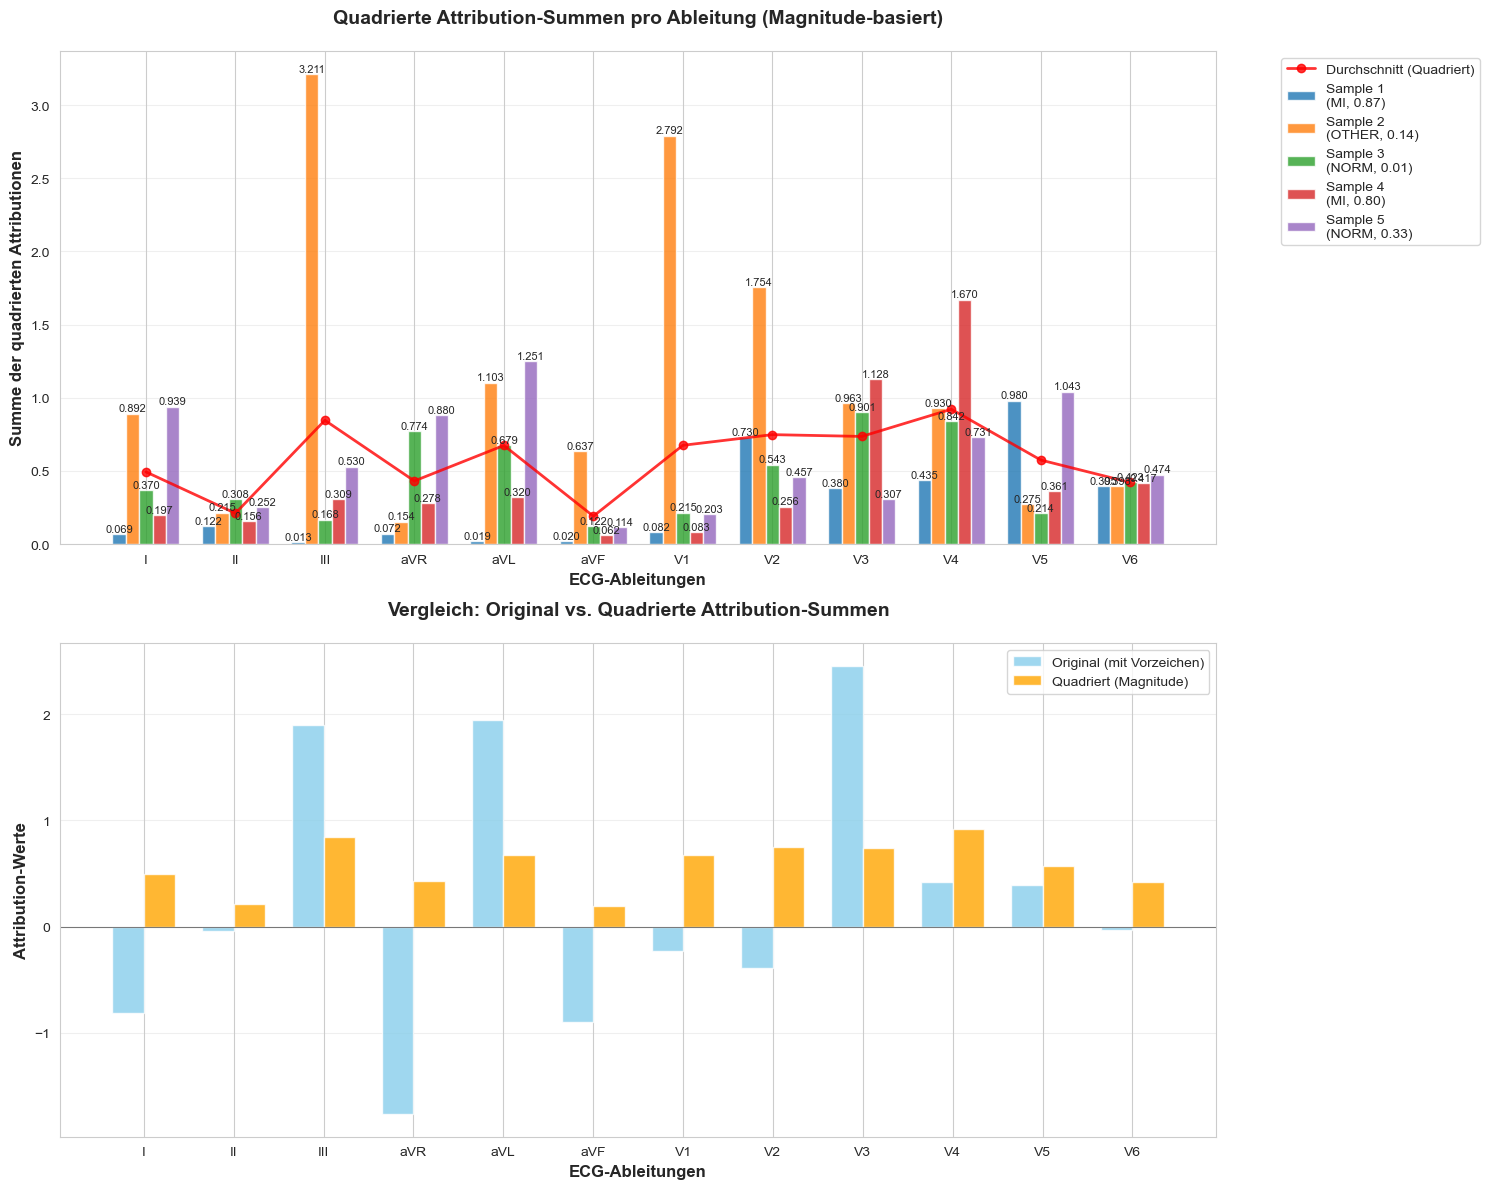


=== STATISTIKEN: Quadrierte Attribution-Summen ===
   I: Original= -0.8106, Quadriert=  0.4935, Std=  0.3578
  II: Original= -0.0399, Quadriert=  0.2107, Std=  0.0665
 III: Original=  1.8949, Quadriert=  0.8460, Std=  1.1944
 aVR: Original= -1.7663, Quadriert=  0.4316, Std=  0.3311
 aVL: Original=  1.9485, Quadriert=  0.6742, Std=  0.4632
 aVF: Original= -0.9012, Quadriert=  0.1908, Std=  0.2261
  V1: Original= -0.2262, Quadriert=  0.6751, Std=  1.0597
  V2: Original= -0.3865, Quadriert=  0.7481, Std=  0.5254
  V3: Original=  2.4559, Quadriert=  0.7359, Std=  0.3296
  V4: Original=  0.4232, Quadriert=  0.9217, Std=  0.4099
  V5: Original=  0.3883, Quadriert=  0.5745, Std=  0.3603
  V6: Original= -0.0295, Quadriert=  0.4212, Std=  0.0284

=== TOP 5 ABLEITUNGEN (Höchste quadrierte Attribution-Summen) ===
1. V4: Quadriert=0.9217, Original=0.4232
2. III: Quadriert=0.8460, Original=1.8949
3. V2: Quadriert=0.7481, Original=-0.3865
4. V3: Quadriert=0.7359, Original=2.4559
5. V1: Quadriert=0.

In [153]:
# =================================================================
# BALKENDIAGRAMM: Quadrierte Attribution-Summen (Magnitude-basiert)
# =================================================================

print("=== BALKENDIAGRAMM: Quadrierte Attribution-Summen ===")
print("💡 Warum quadrieren? → Betont die Wichtigkeit unabhängig vom Vorzeichen!")
print()

# Berechne QUADRIERTE Attribution-Summen pro Ableitung für jedes Sample
attribution_squared_sums_per_lead = []
sample_labels_squared = []

for i, attr_sample in enumerate(all_attributions):
    # attr_sample ist [1, 12, 1000]
    attr_data = attr_sample[0]  # [12, 1000]
    
    # Quadrierte Summe pro Ableitung (über alle 1000 Zeitpunkte)
    lead_squared_sums = np.sum(attr_data**2, axis=1)  # [12] - quadrierte Summe pro Lead
    attribution_squared_sums_per_lead.append(lead_squared_sums)
    
    # Label für Sample
    sample_info_item = sample_info[i]
    predicted_name = sample_info_item['predicted_name']
    confidence = sample_info_item['confidences'][0]  # MI-Confidence
    sample_labels_squared.append(f"Sample {i+1}\n({predicted_name}, {confidence:.2f})")

# Konvertiere zu numpy array
attribution_squared_matrix = np.array(attribution_squared_sums_per_lead)  # [5, 12]
print(f"Squared Attribution Matrix Shape: {attribution_squared_matrix.shape}")

# Erstelle Balkendiagramm für quadrierte Werte
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# ========== PLOT 1: Quadrierte Summen ==========
x_pos = np.arange(len(lead_names))
width = 0.15

# Farben für die 5 Samples
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Plotte quadrierte Balken für jedes Sample
for i in range(num_samples):
    sample_squared_attributions = attribution_squared_matrix[i, :]  # [12]
    offset = (i - 2) * width
    
    bars = ax1.bar(x_pos + offset, sample_squared_attributions, width, 
                   label=sample_labels_squared[i], color=colors[i], alpha=0.8)
    
    # Werte auf Balken (nur bei signifikanten Werten)
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0.01:  # Nur bei größeren Werten
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                    f'{height:.3f}', ha='center', va='bottom', 
                    fontsize=8, rotation=0)

# Durchschnittslinie für quadrierte Werte
avg_squared_attributions_per_lead = np.mean(attribution_squared_matrix, axis=0)  # [12]
ax1.plot(x_pos, avg_squared_attributions_per_lead, 'ro-', linewidth=2, markersize=6, 
         label='Durchschnitt (Quadriert)', color='red', alpha=0.8)

# Styling für Plot 1
ax1.set_xlabel('ECG-Ableitungen', fontsize=12, fontweight='bold')
ax1.set_ylabel('Summe der quadrierten Attributionen', fontsize=12, fontweight='bold')
ax1.set_title('Quadrierte Attribution-Summen pro Ableitung (Magnitude-basiert)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(lead_names)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')

# ========== PLOT 2: Vergleich Original vs. Quadriert ==========
# Durchschnittswerte beider Varianten plotten
avg_original_per_lead = np.mean(attribution_matrix, axis=0)  # Original (mit Vorzeichen)

width_comp = 0.35
x_pos_comp = np.arange(len(lead_names))

bars1 = ax2.bar(x_pos_comp - width_comp/2, avg_original_per_lead, width_comp, 
                label='Original (mit Vorzeichen)', color='skyblue', alpha=0.8)
bars2 = ax2.bar(x_pos_comp + width_comp/2, avg_squared_attributions_per_lead, width_comp, 
                label='Quadriert (Magnitude)', color='orange', alpha=0.8)

# Styling für Plot 2
ax2.set_xlabel('ECG-Ableitungen', fontsize=12, fontweight='bold')
ax2.set_ylabel('Attribution-Werte', fontsize=12, fontweight='bold')
ax2.set_title('Vergleich: Original vs. Quadrierte Attribution-Summen', 
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xticks(x_pos_comp)
ax2.set_xticklabels(lead_names)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

# Statistiken für quadrierte Werte
print()
print("=== STATISTIKEN: Quadrierte Attribution-Summen ===")
for i, lead_name in enumerate(lead_names):
    avg_squared = avg_squared_attributions_per_lead[i]
    std_squared = np.std(attribution_squared_matrix[:, i])
    avg_original = avg_original_per_lead[i]
    print(f"{lead_name:>4}: Original={avg_original:>8.4f}, Quadriert={avg_squared:>8.4f}, Std={std_squared:>8.4f}")

print()
print("=== TOP 5 ABLEITUNGEN (Höchste quadrierte Attribution-Summen) ===")
top_squared_leads_idx = np.argsort(avg_squared_attributions_per_lead)[::-1][:5]
for i, lead_idx in enumerate(top_squared_leads_idx):
    lead_name = lead_names[lead_idx]
    avg_squared = avg_squared_attributions_per_lead[lead_idx]
    avg_original = avg_original_per_lead[lead_idx]
    print(f"{i+1}. {lead_name}: Quadriert={avg_squared:.4f}, Original={avg_original:.4f}")

print()
print("🔍 VORTEILE DER QUADRIERUNG:")
print("  ✅ Magnitude-basiert: Zeigt Wichtigkeit unabhängig vom Vorzeichen")
print("  ✅ Betont starke Attributionen: Große Werte werden verstärkt")
print("  ✅ Eliminiert Auslöschungseffekte: Positive/negative Werte löschen sich nicht aus")
print("  ✅ Bessere Interpretierbarkeit: Höhere Werte = wichtigere Ableitungen")
print()
print("🎯 INTERPRETATION:")
print("  📊 Quadrierte Werte zeigen die 'Aktivität' oder 'Energie' pro Ableitung")
print("  📊 Hohe Werte = Ableitung ist wichtig für die Modellentscheidung")
print("  📊 Niedrige Werte = Ableitung hat wenig Einfluss auf die Entscheidung")

=== BALKENDIAGRAMM: Attribution-Summen pro Ableitung für MI-Klasse ===

Durchschnittliche Attribution-Summen für 5 MI-Samples berechnet
Shape: (12,)



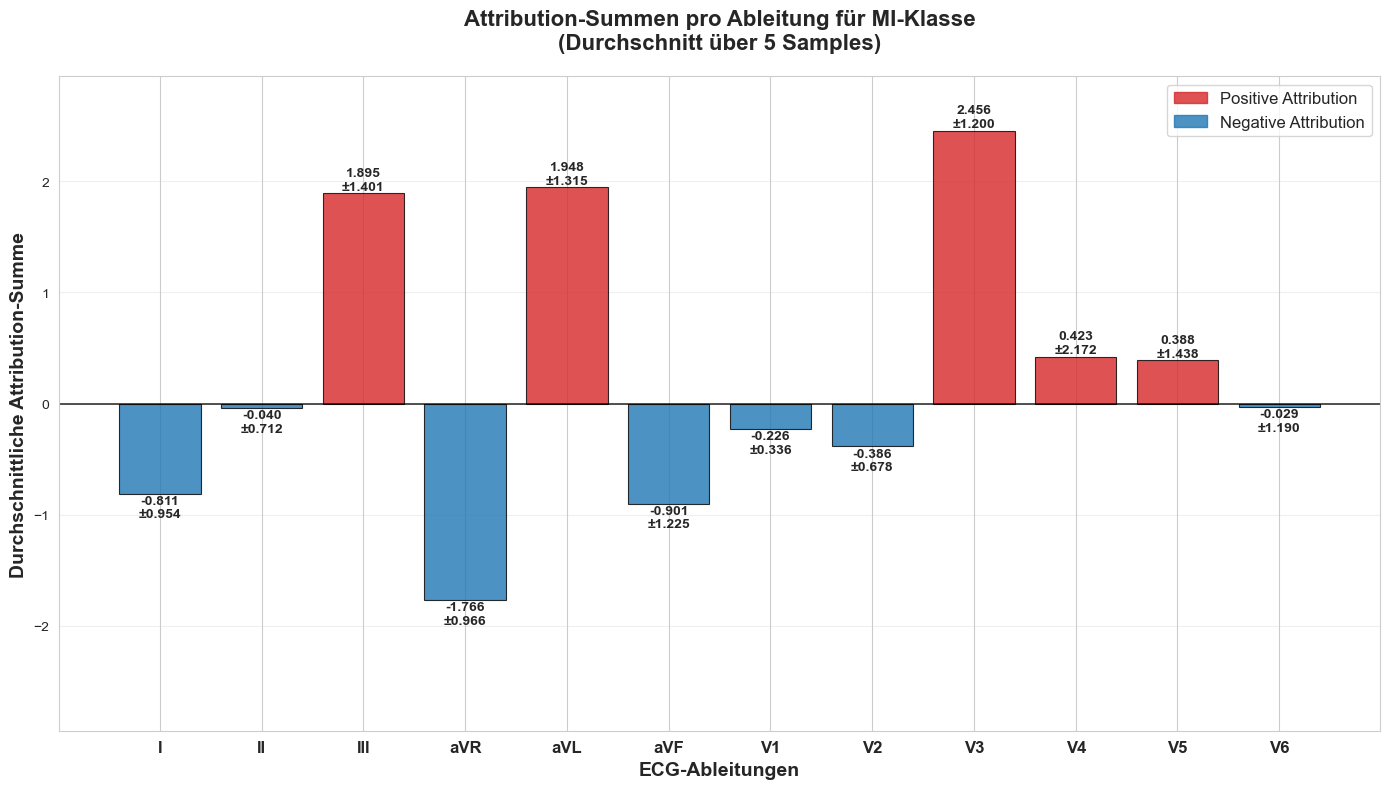

=== DETAILLIERTE STATISTIKEN PRO ABLEITUNG ===
Lead  | Durchschnitt | Std.Abw. | Min      | Max      
------|--------------|----------|----------|----------
   I  |    -0.8106 |   0.9544 |  -1.9881 |   0.6007
  II  |    -0.0399 |   0.7117 |  -0.8886 |   1.0859
 III  |     1.8949 |   1.4013 |  -0.0098 |   3.9549
 aVR  |    -1.7663 |   0.9656 |  -2.9570 |  -0.7027
 aVL  |     1.9485 |   1.3146 |  -0.3189 |   3.6659
 aVF  |    -0.9012 |   1.2252 |  -3.3115 |   0.1278
  V1  |    -0.2262 |   0.3357 |  -0.8809 |   0.0672
  V2  |    -0.3865 |   0.6783 |  -1.0800 |   0.8291
  V3  |     2.4559 |   1.2004 |   0.6641 |   4.2975
  V4  |     0.4232 |   2.1725 |  -1.4639 |   4.5588
  V5  |     0.3883 |   1.4375 |  -1.3508 |   2.1912
  V6  |    -0.0295 |   1.1901 |  -1.1247 |   2.0538

=== RANKING: TOP 5 POSITIVE ATTRIBUTIONEN ===
1. V3: 2.4559
2. aVL: 1.9485
3. III: 1.8949
4. V4: 0.4232
5. V5: 0.3883

=== RANKING: TOP 5 NEGATIVE ATTRIBUTIONEN ===
1. aVR: -1.7663
2. aVF: -0.9012
3. I: -0.8106
4. V2: 

In [154]:
# =================================================================
# EINFACHES BALKENDIAGRAMM: Attribution-Summen nur für MI-Klasse
# =================================================================

print("=== BALKENDIAGRAMM: Attribution-Summen pro Ableitung für MI-Klasse ===")
print()

# Berechne durchschnittliche Attribution-Summen pro Ableitung über alle 5 MI-Samples
# all_attributions enthält die Attributionen für alle 5 MI-Samples
mi_attribution_sums = []

for i, attr_sample in enumerate(all_attributions):
    # attr_sample ist [1, 12, 1000]
    attr_data = attr_sample[0]  # [12, 1000]
    
    # Summe pro Ableitung (über alle 1000 Zeitpunkte)
    lead_sums = np.sum(attr_data, axis=1)  # [12] - eine Summe pro Lead
    mi_attribution_sums.append(lead_sums)

# Berechne Durchschnitt über alle 5 MI-Samples
mi_attribution_matrix = np.array(mi_attribution_sums)  # [5, 12]
avg_mi_attributions = np.mean(mi_attribution_matrix, axis=0)  # [12] - Durchschnitt pro Lead
std_mi_attributions = np.std(mi_attribution_matrix, axis=0)   # [12] - Standardabweichung pro Lead

print(f"Durchschnittliche Attribution-Summen für {num_samples} MI-Samples berechnet")
print(f"Shape: {avg_mi_attributions.shape}")
print()

# Erstelle Balkendiagramm
fig, ax = plt.subplots(figsize=(14, 8))

# X-Positionen für die Ableitungen
x_pos = np.arange(len(lead_names))

# Farbe basierend auf positiven/negativen Werten
colors = ['#d62728' if val >= 0 else '#1f77b4' for val in avg_mi_attributions]  # Rot für positiv, Blau für negativ

# Erstelle Balken
bars = ax.bar(x_pos, avg_mi_attributions, color=colors, alpha=0.8, 
              edgecolor='black', linewidth=0.8)

# Füge Werte auf die Balken
for i, (bar, value, std_val) in enumerate(zip(bars, avg_mi_attributions, std_mi_attributions)):
    height = bar.get_height()
    # Platziere Text über oder unter dem Balken je nach Vorzeichen
    y_offset = 0.005 if height >= 0 else -0.01
    ax.text(bar.get_x() + bar.get_width()/2., height + y_offset,
           f'{value:.3f}\n±{std_val:.3f}', ha='center', 
           va='bottom' if height >= 0 else 'top', 
           fontsize=10, fontweight='bold')

# Styling
ax.set_xlabel('ECG-Ableitungen', fontsize=14, fontweight='bold')
ax.set_ylabel('Durchschnittliche Attribution-Summe', fontsize=14, fontweight='bold')
ax.set_title(f'Attribution-Summen pro Ableitung für MI-Klasse\n(Durchschnitt über {num_samples} Samples)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(lead_names, fontsize=12, fontweight='bold')

# Grid und Null-Linie
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.2, alpha=0.8)

# Y-Achse symmetrisch um 0 machen
max_abs_val = max(abs(np.min(avg_mi_attributions)), abs(np.max(avg_mi_attributions)))
margin = max_abs_val * 0.2
ax.set_ylim(-max_abs_val - margin, max_abs_val + margin)

# Legende
positive_patch = plt.Rectangle((0, 0), 1, 1, color='#d62728', alpha=0.8, label='Positive Attribution')
negative_patch = plt.Rectangle((0, 0), 1, 1, color='#1f77b4', alpha=0.8, label='Negative Attribution')
ax.legend(handles=[positive_patch, negative_patch], loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

# Detaillierte Statistiken
print("=== DETAILLIERTE STATISTIKEN PRO ABLEITUNG ===")
print("Lead  | Durchschnitt | Std.Abw. | Min      | Max      ")
print("------|--------------|----------|----------|----------")
for i, lead_name in enumerate(lead_names):
    avg_val = avg_mi_attributions[i]
    std_val = std_mi_attributions[i]
    min_val = np.min(mi_attribution_matrix[:, i])
    max_val = np.max(mi_attribution_matrix[:, i])
    print(f"{lead_name:>4}  | {avg_val:>10.4f} | {std_val:>8.4f} | {min_val:>8.4f} | {max_val:>8.4f}")

print()
print("=== RANKING: TOP 5 POSITIVE ATTRIBUTIONEN ===")
top_positive_idx = np.argsort(avg_mi_attributions)[::-1][:5]
for i, lead_idx in enumerate(top_positive_idx):
    if avg_mi_attributions[lead_idx] > 0:
        lead_name = lead_names[lead_idx]
        avg_val = avg_mi_attributions[lead_idx]
        print(f"{i+1}. {lead_name}: {avg_val:.4f}")

print()
print("=== RANKING: TOP 5 NEGATIVE ATTRIBUTIONEN ===")
top_negative_idx = np.argsort(avg_mi_attributions)[:5]
for i, lead_idx in enumerate(top_negative_idx):
    if avg_mi_attributions[lead_idx] < 0:
        lead_name = lead_names[lead_idx]
        avg_val = avg_mi_attributions[lead_idx]
        print(f"{i+1}. {lead_name}: {avg_val:.4f}")